# Q2 Two-Level Multigrid Acceleration

Uses direct Python ports of the MATLAB files (`GS.m`, `residual.m`, `restrict.m`, `interpolate.m`, `MultigridV.m`).

Solves $(1-M_\infty^2)\phi_{xx} + \phi_{yy} = 0$ with Neumann BCs.
Compares plain GS vs two-level V-cycle multigrid.

In [166]:
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter

from utils import (
    dYb_dx, neumann_bcs, fix_gauge,
    residual_interior, phi_update_size, Usurf_on_y0, compute_uv,
)
from Q2.m_functions import GS, residual, restrict, interpolate, MultigridV

eps, M = 0.1, 0.2
q, s, r = 4.0, 4.0, 4.0
TOL = 1e-5

In [156]:
def make_bc_funcs(x, eps, dx, dy, anchor=(0,0)):
    """Create BC callback functions for fine and coarse grids."""
    g_bottom = dYb_dx(x, eps)
    
    def bc_fine(phi):
        neumann_bcs(phi, g_bottom, dx, dy)
        fix_gauge(phi, anchor)
    
    def bc_coarse(phi):
        Nx, Ny = phi.shape
        phi[:, 0]    = (4*phi[:, 1]    - phi[:, 2])    / 3.
        phi[:, Ny-1] = (4*phi[:, Ny-2] - phi[:, Ny-3]) / 3.
        phi[0, :]    = (4*phi[1, :]    - phi[2, :])    / 3.
        phi[Nx-1, :] = (4*phi[Nx-2, :] - phi[Nx-3, :]) / 3.
        phi -= phi[0, 0]
    
    return g_bottom, bc_fine, bc_coarse


def run_plain_gs(Nx, Ny, tol=TOL, max_iter=80000, check_every=500):
    """Run plain GS and return (phi, x, info_dict)."""
    x = np.linspace(-q, s, Nx); y = np.linspace(0., r, Ny)
    dx, dy = float(x[1]-x[0]), float(y[1]-y[0])
    lam = (1.-M**2)*(dy/dx)**2
    g, bcf, _ = make_bc_funcs(x, eps, dx, dy)
    f0 = np.zeros((Nx, Ny))
    
    phi = np.zeros((Nx, Ny)); bcf(phi)
    res0 = residual_interior(phi, M, dx, dy)
    t0 = perf_counter()
    hist = []
    last_phi = phi.copy()
    
    for it in range(1, max_iter+1):
        GS(phi, f0, 1, lam, dy, bc_func=bcf)
        if it % check_every == 0 or it == 1:
            res = residual_interior(phi, M, dx, dy)
            upd = phi_update_size(last_phi, phi)
            hist.append({'it': it, 'res': res, 'upd': upd, 'time': perf_counter()-t0})
            if res < tol and upd < tol:
                break
            last_phi = phi.copy()
    
    return phi, x, {'converged': res<tol, 'iters': it,
                     'seconds': perf_counter()-t0, 'hist': hist, 'dx': dx}


def run_multigrid(Nx, Ny, nu_pre=3, nu_post=3, nu_c=20, tol=TOL, max_cyc=3000):
    """Run multigrid V-cycles and return (phi, x, info_dict)."""
    x = np.linspace(-q, s, Nx); y = np.linspace(0., r, Ny)
    dx, dy = float(x[1]-x[0]), float(y[1]-y[0])
    lam = (1.-M**2)*(dy/dx)**2
    g, bcf, bcc = make_bc_funcs(x, eps, dx, dy)
    f0 = np.zeros((Nx, Ny))
    
    phi = np.zeros((Nx, Ny)); bcf(phi)
    res0 = residual_interior(phi, M, dx, dy)
    t0 = perf_counter()
    hist = []
    
    for cyc in range(1, max_cyc+1):
        last_phi = phi.copy()
        phi = MultigridV(phi, f0, lam, dy, bc_func=bcf,
                         nu_pre=nu_pre, nu_post=nu_post, nu_coarse=nu_c,
                         bc_func_coarse=bcc)
        res = residual_interior(phi, M, dx, dy)
        upd = phi_update_size(last_phi, phi)
        hist.append({'cyc': cyc, 'res': res, 'upd': upd, 'time': perf_counter()-t0})
        if res < tol and upd < tol:
            break
    
    return phi, x, {'converged': res<tol, 'cycles': cyc,
                     'seconds': perf_counter()-t0, 'hist': hist, 'dx': dx,
                     'params': {'nu_pre': nu_pre, 'nu_post': nu_post, 'nu_c': nu_c}}

1. Baseline comparison: plain GS vs multigrid (161×81)

In [164]:
Nx, Ny = 161, 81

print("=== Plain GS ===")
phi_gs, x, info_gs = run_plain_gs(Nx, Ny)
print(f"  converged={info_gs['converged']}  iters={info_gs['iters']}  time={info_gs['seconds']:.2f}s")

print("\n=== Multigrid V(3,3), v_c=20 ===")
phi_mg, _, info_mg1 = run_multigrid(Nx, Ny, nu_pre=3, nu_post=3, nu_c=20)
su1 = info_gs['seconds'] / max(info_mg1['seconds'], 1e-9)
print(f"  cycles={info_mg1['cycles']}  time={info_mg1['seconds']:.2f}s  speedup={su1:.1f}×")

print("\n=== Multigrid V(5,5), v_c=30 ===")
phi_mg2, _, info_mg2 = run_multigrid(Nx, Ny, nu_pre=5, nu_post=5, nu_c=30)
su2 = info_gs['seconds'] / max(info_mg2['seconds'], 1e-9)
print(f"  cycles={info_mg2['cycles']}  time={info_mg2['seconds']:.2f}s  speedup={su2:.1f}×")

=== Plain GS ===
  converged=True  iters=35500  time=7.03s

=== Multigrid V(3,3), v_c=20 ===
  cycles=458  time=1.24s  speedup=5.7×

=== Multigrid V(5,5), v_c=30 ===
  cycles=297  time=1.22s  speedup=5.7×


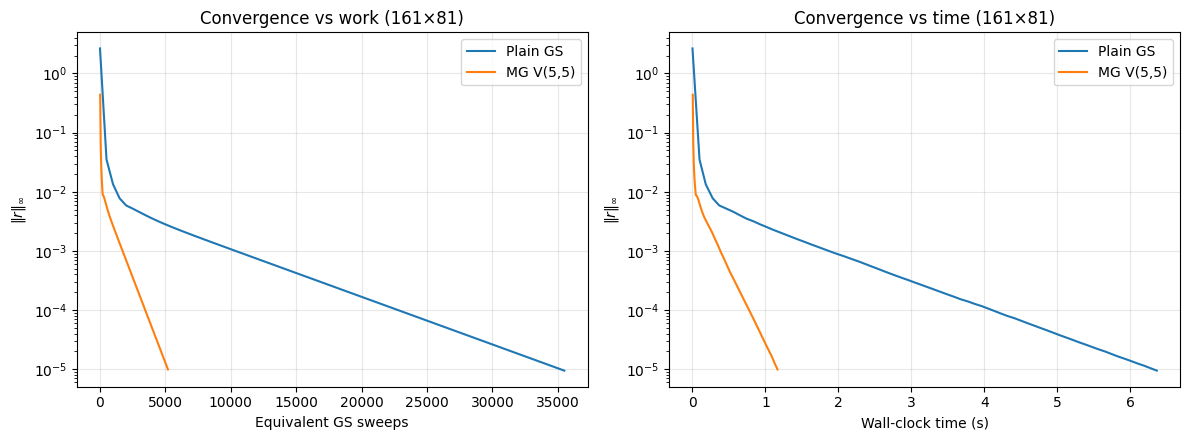

In [ ]:
# Convergence comparison 
h_gs = info_gs['hist']
h_mg = info_mg2['hist']   # V(5,5)

t_gs  = np.array([d['time'] for d in h_gs])
r_gs  = np.array([d['res']  for d in h_gs])
it_gs = np.array([d['it']   for d in h_gs])

t_mg  = np.array([d['time'] for d in h_mg])
r_mg  = np.array([d['res']  for d in h_mg])
cyc_mg = np.array([d['cyc'] for d in h_mg])

# Work units: each V-cycle ≈ (nu_pre + nu_post + nu_c/4) fine-GS-sweep equivalents
work_per_cyc = 5 + 5 + 30/4.0
equiv_mg = cyc_mg * work_per_cyc

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].semilogy(it_gs, r_gs, label='Plain GS')
axes[0].semilogy(equiv_mg, r_mg, label='MG V(5,5)')
axes[0].set_xlabel('Equivalent GS sweeps')
axes[0].set_ylabel(r'$\|r\|_\infty$')
axes[0].set_title(f'Convergence vs work ({Nx}×{Ny})')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].semilogy(t_gs, r_gs, label='Plain GS')
axes[1].semilogy(t_mg, r_mg, label='MG V(5,5)')
axes[1].set_xlabel('Wall-clock time (s)')
axes[1].set_ylabel(r'$\|r\|_\infty$')
axes[1].set_title(f'Convergence vs time ({Nx}x{Ny})')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('q2_fig_conv_history.png', dpi=150, bbox_inches='tight')
plt.show()

2. Solution verification

max|Usurf_GS − Usurf_MG| on [−1,1]: 3.58e-06


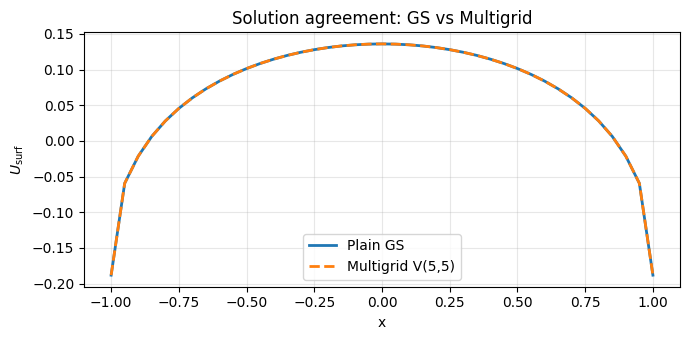

In [ ]:
u_gs = Usurf_on_y0(phi_gs, info_gs['dx'])
u_mg = Usurf_on_y0(phi_mg2, info_mg2['dx'])
mask = (x >= -1) & (x <= 1)
diff = np.max(np.abs(u_gs[mask] - u_mg[mask]))
print(f"max|Usurf_GS - Usurf_MG| on [-1,1]: {diff:.2e}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(x[mask], u_gs[mask], lw=2, label='Plain GS')
ax.plot(x[mask], u_mg[mask], '--', lw=2, label='Multigrid V(5,5)')
ax.set_xlabel('x'); ax.set_ylabel(r'$U_{\mathrm{surf}}$')
ax.set_title('Solution agreement: GS vs Multigrid')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q2_fig_solution_check.png', dpi=150, bbox_inches='tight')
plt.show()

3. Convergence factor per V-cycle

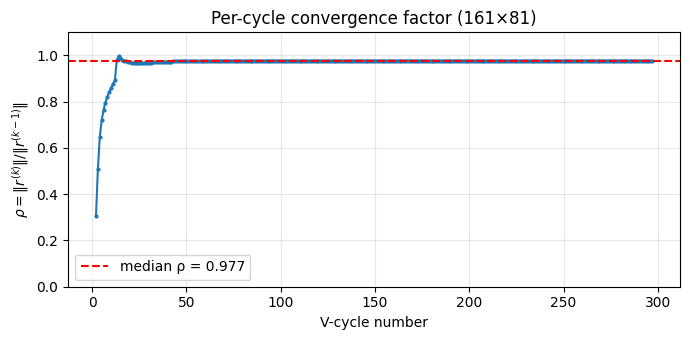

In [ ]:
res_arr = np.array([d['res'] for d in h_mg])
rho = res_arr[1:] / res_arr[:-1]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(range(2, len(res_arr)+1), rho, 'o-', markersize=2)
med_rho = np.median(rho[min(10, len(rho)-1):])
ax.axhline(med_rho, color='r', ls='--', label=f'median ρ = {med_rho:.3f}')
ax.set_xlabel('V-cycle number')
ax.set_ylabel(r'$\rho = \|r^{(k)}\| / \|r^{(k-1)}\|$')
ax.set_title(f'Per-cycle convergence factor ({Nx}×{Ny})')
ax.set_ylim(0, 1.1); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q2_fig_conv_factor.png', dpi=150, bbox_inches='tight')
plt.show()

4. Effect of smoothing parameters

In [165]:
Nx, Ny = 161, 81
configs = [
    (2, 2, 10), (2, 2, 20), (2, 2, 40),
    (3, 3, 10), (3, 3, 20), (3, 3, 40),
    (5, 5, 10), (5, 5, 20), (5, 5, 30),
    (10, 10, 10), (10, 10, 20), (10, 10, 30),
]
print(f"{'Config':<20s} {'Cycles':>6s} {'Time(s)':>8s}")
print("-" * 38)
for n1, n2, nc in configs:
    _, _, info = run_multigrid(Nx, Ny, nu_pre=n1, nu_post=n2, nu_c=nc)
    tag = f"V({n1},{n2}), v_c={nc}"
    print(f"{tag:<20s} {info['cycles']:6d} {info['seconds']:8.2f}")

Config               Cycles  Time(s)
--------------------------------------
V(2,2), v_c=10          913     1.58
V(2,2), v_c=20          476     1.00
V(2,2), v_c=40          243     0.76
V(3,3), v_c=10          859     1.76
V(3,3), v_c=20          458     1.15
V(3,3), v_c=40          237     0.85
V(5,5), v_c=10          774     2.24
V(5,5), v_c=20          429     1.71
V(5,5), v_c=30          297     1.22
V(10,10), v_c=10        627     3.06
V(10,10), v_c=20        378     2.08
V(10,10), v_c=30        270     1.62


5. Grid-scaling

In [ ]:
grids = [(81, 41), (161, 81)]

print(f"{'Grid':<10s} {'GS iters':>8s} {'GS(s)':>7s} {'MG cyc':>7s} {'MG(s)':>7s} {'Speedup':>8s}")
print("-" * 54)
scale_data = []

for Nxi, Nyi in grids:
    _, _, ig = run_plain_gs(Nxi, Nyi)
    _, _, im = run_multigrid(Nxi, Nyi, nu_pre=5, nu_post=5, nu_c=30)
    su = ig['seconds'] / max(im['seconds'], 1e-9)
    print(f"{Nxi}x{Nyi:<6d} {ig['iters']:8d} {ig['seconds']:7.2f} "
          f"{im['cycles']:7d} {im['seconds']:7.2f} {su:8.1f}x")
    scale_data.append((Nxi*Nyi, ig['iters'], ig['seconds'], im['cycles'], im['seconds']))

# MG-only for 241×121 (GS too slow)
print("\n241x121: multigrid only (plain GS too slow)")
_, _, im_big = run_multigrid(241, 121, nu_pre=5, nu_post=5, nu_c=30)
print(f"  MG: {im_big['cycles']} cycles, {im_big['seconds']:.2f}s")
scale_data.append((241*121, None, None, im_big['cycles'], im_big['seconds']))

Grid       GS iters   GS(s)  MG cyc   MG(s)  Speedup
------------------------------------------------------
81×41        11000    0.59      79    0.11      5.5×
161×81        35500    7.30     297    1.15      6.3×

241×121: multigrid only (plain GS too slow)
  MG: 656 cycles, 5.50s


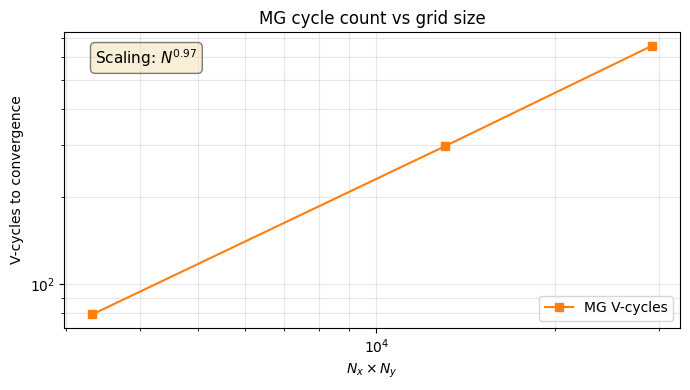

In [163]:
N_arr  = np.array([d[0] for d in scale_data])
mg_cyc = np.array([d[3] for d in scale_data])
mg_t   = np.array([d[4] for d in scale_data])

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(N_arr, mg_cyc, 's-', label='MG V-cycles', color='C1')
ax.set_xlabel(r'$N_x \times N_y$')
ax.set_ylabel('V-cycles to convergence')
ax.set_title('MG cycle count vs grid size')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
# Annotate scaling
if len(mg_cyc) >= 2:
    slope = np.log(mg_cyc[-1]/mg_cyc[0]) / np.log(N_arr[-1]/N_arr[0])
    ax.text(0.05, 0.95, f'Scaling: $N^{{{slope:.2f}}}$',
            transform=ax.transAxes, va='top', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.savefig('q2_fig_grid_scaling.png', dpi=150, bbox_inches='tight')
plt.show()